<a href="https://colab.research.google.com/github/wecwic/beleg-dl-gruppe-1/blob/main/Belegaufgabe_Gruppe_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Belegarbeit Deep Learning für sequentielle Prozessdaten SS2023




# Beleggruppe

Gruppen_ID = 1

Namen: (Surname, First Name, Martikelnummer)

In [2]:
## List of Classes for Classification
selected_axes = ['Acc_X', 'Acc_Y']
selected_classes = ['Gut', 'Mangelschmierung', 'Pitting_V1']

# 0. Bibliotheken importieren

In [30]:
# benötigte Bibliotheken importieren
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix
import optuna

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

%matplotlib inline
import torch

from torch.utils.data import Dataset, DataLoader, Subset

import torch.nn as nn
import torchmetrics

# 1. Daten erfassen - Daten importieren

In [3]:
# Für Nutzung in Google Colab: Mount Google Drive to access the dataset

# from google.colab import drive
# drive.mount('/content/drive')
# data_path = '/content/drive/MyDrive/DL_Daten/Datensatz.csv'

In [11]:
# Lade Datensatz und Ausgabe Zufallszahl
# Für lokale Nutzung, bitte den Pfad zum Datensatz anpassen

# data_path = 'LINK ZUM DATENSATZ'
data_path = r'C:\dev\beleg-dl-gruppe-1\Datensatz.csv'
df = pd.read_csv(data_path)

df.head(-1)

,Unnamed: 0,index,Acc_X,Acc_Y,Acc_Z,time_ms,rel_time_ms,run_ID,run_status,Status,Velocity,label
0,0,162826,0.040562,0.002472,0.009140,1617806910987,66366,1,-1,Gut,10000,0
1,1,162827,0.040991,0.002469,0.009149,1617806910987,66366,1,-1,Gut,10000,0
2,2,162828,0.041417,0.002465,0.009149,1617806910987,66366,1,-1,Gut,10000,0
3,3,162829,0.041843,0.002461,0.009150,1617806910987,66366,1,-1,Gut,10000,0
4,4,162830,0.024225,-0.001714,-0.000699,1617806910988,66367,1,-1,Gut,10000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4766612,4766612,7243883,0.008971,0.015505,0.015365,1617961507532,707926,813,1,Pitting_V4,10000,5
4766613,4766613,7243884,0.008952,0.015507,0.015378,1617961507532,707926,813,1,Pitting_V4,10000,5
4766614,4766614,7243885,0.025855,0.004554,-0.009693,1617961507533,707927,813,1,Pitting_V4,10000,5
4766615,4766615,7243886,0.025830,0.004561,-0.009681,1617961507533,707927,813,1,Pitting_V4,10000,5


# 2. Daten Vorverarbeitung

In [16]:
####################################################################################################################################################################################################################################################### DIESEN BLOCK NICHT ÄNDERN #########################################################################################
#######################################################################################################################################################################################

def to_categorical(y, num_classes):
    """ 1-hot encodes a tensor """
    return np.eye(num_classes, dtype='uint8')[y]

def data_preprocessing(selected_axes=['Acc_X', 'Acc_Y', 'Acc_Z'], selected_classes=['Gut', 'Mangelschmierung', 'Pitting_V1', 'Pitting_V2', 'Pitting_V3', 'Pitting_V4'], x_len=2500):  # Select which Acc-Data should be included axis: ['Acc_X', 'Acc_Y', 'Acc_Z']
    # file_path = r'd:\Nutzer\boos\_Arbeit\3. IWM-Prozesskette\7. Datensaetze\Boschbett\\PS_total_10000.csv'
    file_path = r'C:\dev\beleg-dl-gruppe-1\Datensatz.csv'
    df = pd.read_csv(file_path)
    df = df.drop(df.columns[0:2], axis=1)
    df = df[df['Status'].isin(selected_classes)]

    maxlen = df['run_ID'].value_counts().max()

    if len(selected_classes) < 6:
        label_arr_old = df['label'].values
        label_arr_new = np.zeros(shape=label_arr_old.shape)
        label_arr = np.vstack((label_arr_old, label_arr_new)).T
        i = int(0)
        for idx in np.unique(label_arr_old):
            label_arr[np.where(label_arr[:, 0] == idx), 1] = i
            i += 1
        label_arr = label_arr.astype(int)
        df['label'] = df['label'].map(dict(label_arr))

    n_classes = len(df['label'].value_counts())
    Load = df[['label', 'run_ID']]
    drop_cols = ['label', 'Status', ]
    drop_cols = list(set(drop_cols) & set(df.columns))  # Check if cols are part of df and select only those
    df = df.drop(columns=drop_cols).reset_index(drop=True)
    input_column_names = selected_axes
    x_columns = input_column_names + ['run_ID']
    g = df.groupby('run_ID').cumcount()
    X = (df[x_columns].set_index(['run_ID', g])
         .unstack(fill_value=0)
         .stack().groupby(level=0)
         .apply(lambda x: x.values)
         .to_numpy())
    X = np.array([i for i in X])
    if x_len is not None:
        X = X[:, 0:x_len, :]
        maxlen = x_len
    # del df  <- in case of memory issues
    g = Load.groupby('run_ID').cumcount()

    y = (Load.set_index(['run_ID', g])
         .unstack(fill_value=0)
         .stack().groupby(level=0)
         .apply(lambda x: x.values[0]))
         #.to_numpy().astype("int32"))
    y = np.array(y.tolist(), dtype="int32") # <--- Fix according to Gemini
    
    y = to_categorical(y, n_classes)

    return X, y, maxlen

# 3. Daten für Modell vorbereiten - DataSet Class, Aufteilung in X und y, Normierung

In [7]:
## Define DataSet Class
class DataSet(Dataset):
    # load the dataset
    def __init__(self, X, y):
        self.X = X
        self.y = y

    # number of rows in the dataset
    def __len__(self):
        return len(self.X)

    # get a row at an index
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]).float(), torch.from_numpy(self.y[idx]).float()

In [17]:
## Data Preprocessing
X, y, maxlen = data_preprocessing(selected_axes=selected_axes,
                                  selected_classes=selected_classes)

## Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    shuffle=True,
                                                    random_state=random.randint(2, 128))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.33,
                                                  shuffle=True,
                                                  random_state=random.randint(2, 128))

## Normalize Data
scaler = StandardScaler().fit(np.vstack(X_train))
X_train = scaler.transform(np.vstack(X_train)).reshape(len(X_train), X[0].shape[0], -1)
X_val = scaler.transform(np.vstack(X_val)).reshape(len(X_val), X[0].shape[0], -1)
X_test = scaler.transform(np.vstack(X_test)).reshape(len(X_test), X[0].shape[0], -1)

## Declare Datasets
train_dataset = DataSet(X_train, y_train)
val_dataset = DataSet(X_val, y_val)
test_dataset = DataSet(X_test, y_test)

# Define DataLoaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Aufgabenstellung

In [ ]:
"""
Entwickeln Sie ein DL-Modell, welches für die Multiklassen-Klassifikation geeignet ist. 
Zum Bestehen des Belegaufgabe reicht es ein funktionierendes Modell zu entwickeln, welches 
eine Test-Accuracy von mindestens 55% aufweist. Nutzen Sie alle im Rahmen der Übung 
vorgestellten Methoden zur Entwicklung und Verbesserung des Modells. Die gewählte Lösungsstrategie 
sowie die Modellarchitektur und der Programmcode bestimmen die Note, weniger die Höhe der 
Modellgenauigkeit (solange diese über 55% liegt). Daher bitte ich Sie jeden Lösungsschritt klar 
zu dokumentieren und falls nötig zu kommentieren. Der bereitgestellte Code dient als Grundlage 
und kann beliebig erweitert werden. Lediglich die Funktionen "data_preprocessing" und 
"to_categorical" dürfen nicht verändert werden, sowie die belegspezifischen Variablen 
selected_axes & selected_classes.

Zur Abgabe reichen Sie bitte dieses ausgefüllte Jupyter-Notebook ein. Sollten Sie weiteren 
Dokumente (Notebooks, Word-/ Excel-/ TXT-Dateien) befügen wollen, können Sie das gerne vornehmen.

Die Abgabe der Belegarbeit erfolgt zur Deadline im angelegten TU-Cloud Ordner der zugehörigen Gruppe.

Hinweise:
- Es handelt sich um eine Multiklassen-Klassifikation mit 3 Klassen, keine Binärklassifikation!
--> siehe "selected_classes"
--> Achten Sie bitte auf die Anzahl der Neuronen im Output-Layer & Nutzen Sie den One-Hot-Encodern
(siehe https://towardsdatascience.com/target-encoding-for-multi-class-classification-c9a7bcb1a53)
--> Achten Sie bitte auf die Loss-Funktion 
--> Achten Sie bitte auf die Aktivierungsfunktion im Output-Layer
- der Datensatz baut sich aus mehreren Features auf (Beschleunigungsrichtungen --> siehe "selected_axes")
- Nutzen Sie die in der Übung vorgestellten Tuning Methoden zur Verbesserung des Modells
- Nutzen Sie Optuna für die Hyperparameteroptimierung, falls notwendig

- Ich empfehle für die Entwicklung des Modells eine IDE zu verwenden (z.B. PyCharm, Spyder, etc.) und nicht ausschließlich das Jupyter-Notebook.
"""

In [18]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (186, 2500, 2)
y_train shape: (186, 1, 3)


In [19]:
# Baseline 1D-CNN Model (according to Gemini)

import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # 1. First Convolutional Block (Looking for basic vibration patterns)
        # in_channels=2 because we have Acc_X and Acc_Y
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=5) 
        # After pooling, sequence length drops from 2500 to 500
        
        # 2. Second Convolutional Block (Looking for complex patterns like "Pitting")
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=5) 
        # After pooling again, sequence length drops from 500 to 100
        
        # 3. Fully Connected (Dense) Classifier
        # 32 channels * 100 sequence length = 3200 flattened features
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3200, 64)
        self.relu3 = nn.ReLU()
        
        # OUTPUT LAYER: Exactly 3 neurons for your 3 classes (Gut, Mangelschmierung, Pitting_V1)
        self.fc2 = nn.Linear(64, 3) 

    def forward(self, x):
        # --- THE PYTORCH QUIRK FIX ---
        # Numpy gives us data in shape: (Batch, Sequence, Features) -> (64, 2500, 2)
        # PyTorch Conv1d demands shape: (Batch, Features, Sequence) -> (64, 2, 2500)
        # .permute() flips those last two dimensions instantly so it doesn't crash!
        x = x.permute(0, 2, 1) 
        
        # Pass data through the first block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Pass data through the second block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Flatten and Classify
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x) 
        
        # Notice: No Softmax here! CrossEntropyLoss handles it automatically.
        return x

# Initialize the model to make sure it doesn't crash
model = BaselineCNN()
print(model)

BaselineCNN(
  (conv1): Conv1d(2, 16, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3200, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


In [20]:
# The Loss Function for Multi-Class problems (Gemini)
criterion = nn.CrossEntropyLoss()

# The Optimizer (Adam is standard and fast) (Gemini)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
# --- 1. SET UP THE DATA CONVEYOR BELTS --- (Gemini)
# Wrap the numpy arrays in the professor's DataSet class
train_dataset = DataSet(X_train, y_train)
val_dataset = DataSet(X_val, y_val)

# Create the DataLoaders (feeds data in batches of 64)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# --- 2. THE TRAINING LOOP ---
epochs = 10 # We are keeping it low just to test if it crashes

print("Starting the engine...")

for epoch in range(epochs):
    model.train() # Put the model into training mode
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Step A: Clear the old memories (gradients)
        optimizer.zero_grad()
        
        # Step B: PyTorch demands float32 data types, so we convert them
        batch_X = batch_X.float()
        batch_y = batch_y.float()
        
        # Step C: Forward Pass (Let the model guess)
        predictions = model(batch_X)

        # --- THE FIX ---
        # Convert the one-hot target arrays back into simple class indices (0, 1, or 2)
        # and make sure they are LongTensors (which CrossEntropyLoss demands)
        target_indices = torch.argmax(batch_y.view(-1,3), dim=1).long()
        
        # Step D: Calculate how wrong the guesses were
        # loss = criterion(predictions, batch_y)
        loss = criterion(predictions, target_indices)

        # Step E: Backward Pass (Calculate the fixes)
        loss.backward()
        
        # Step F: Optimizer updates the weights
        optimizer.step()
        
        running_loss += loss.item()
        
    # Print the average loss for this epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Training Loss: {avg_loss:.4f}")

print("Training complete! The engine works!")

Starting the engine...
Epoch 1/10 | Training Loss: 1.1088
Epoch 2/10 | Training Loss: 1.0918
Epoch 3/10 | Training Loss: 1.0617
Epoch 4/10 | Training Loss: 1.0170
Epoch 5/10 | Training Loss: 0.9796
Epoch 6/10 | Training Loss: 0.9303
Epoch 7/10 | Training Loss: 0.8824
Epoch 8/10 | Training Loss: 0.8279
Epoch 9/10 | Training Loss: 0.7727
Epoch 10/10 | Training Loss: 0.6949
Training complete! The engine works!


In [25]:
# --- 3. THE EVALUATION LOOP ---
# We put the model in evaluation mode (turns off training-only features like Dropout)
model.eval()

correct_guesses = 0
total_samples = 0

print("Testing the model on Validation Data...")

# torch.no_grad() tells PyTorch to stop tracking gradients (saves memory and speeds up testing)
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        # 1. Convert types
        batch_X = batch_X.float()
        batch_y = batch_y.float()
        
        # 2. Get the model's raw guesses
        predictions = model(batch_X)
        
        # 3. Convert guesses into class numbers (0, 1, or 2)
        predicted_classes = torch.argmax(predictions, dim=1)
        
        # 4. Convert true answers into class numbers (using our shape fix from earlier!)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        # 5. Count how many we got right
        total_samples += true_classes.size(0)
        correct_guesses += (predicted_classes == true_classes).sum().item()

# Calculate the final percentage
val_accuracy = 100 * correct_guesses / total_samples
print(f"Validation Accuracy: {val_accuracy:.2f}%")

if val_accuracy >= 55.0:
    print("🎉 YOU BEAT THE 55% THRESHOLD! 🎉")
else:
    print("Not at 55% yet. Time to train longer or tune the hyperparameters!")

Testing the model on Validation Data...
Validation Accuracy: 63.04%
🎉 YOU BEAT THE 55% THRESHOLD! 🎉


In [26]:
# --- 4. Test LOOP ---
# We put the model in evaluation mode (turns off training-only features like Dropout)
model.eval()

correct_guesses = 0
total_samples = 0

print("Testing the model on testing Data...")

test_loader = DataLoader(DataSet(X_test, y_test), batch_size=64, shuffle=False)

# torch.no_grad() tells PyTorch to stop tracking gradients (saves memory and speeds up testing)
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # 1. Convert types
        batch_X = batch_X.float()
        batch_y = batch_y.float()
        
        # 2. Get the model's raw guesses
        predictions = model(batch_X)
        
        # 3. Convert guesses into class numbers (0, 1, or 2)
        predicted_classes = torch.argmax(predictions, dim=1)
        
        # 4. Convert true answers into class numbers (using our shape fix from earlier!)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        # 5. Count how many we got right
        total_samples += true_classes.size(0)
        correct_guesses += (predicted_classes == true_classes).sum().item()

# Calculate the final percentage
val_accuracy = 100 * correct_guesses / total_samples
print(f"Validation Accuracy: {val_accuracy:.2f}%")

if val_accuracy >= 55.0:
    print("🎉 YOU BEAT THE 55% THRESHOLD! 🎉")
else:
    print("Not at 55% yet. Time to train longer or tune the hyperparameters!")

Testing the model on testing Data...
Validation Accuracy: 56.99%
🎉 YOU BEAT THE 55% THRESHOLD! 🎉


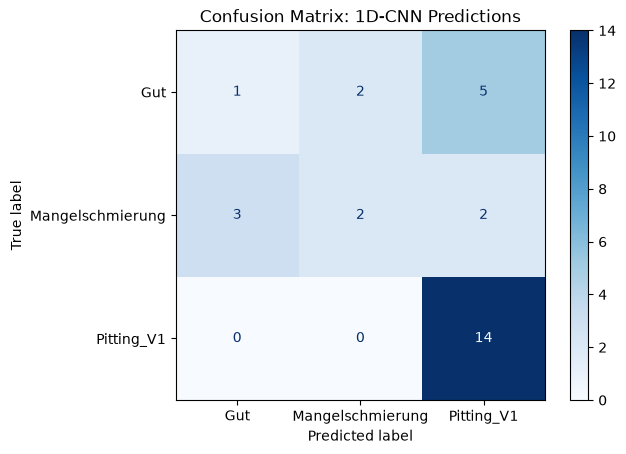

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

# Draw the Confusion Matrix
cm = confusion_matrix(true_classes.cpu(), predicted_classes.cpu())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: 1D-CNN Predictions")
plt.show()

In [31]:
import optuna

print("Initiating Optuna Hyperparameter Search...")

def objective(trial):
    # 1. OPTUNA'S CHOICES: Let Optuna pick the Learning Rate and the size of the Linear Layer
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    fc_size = trial.suggest_categorical("fc_size", [32, 64, 128])
    
    # 2. BUILD THE DYNAMIC MODEL
    class TunedCNN(nn.Module):
        def __init__(self, fc_size):
            super(TunedCNN, self).__init__()
            self.conv1 = nn.Conv1d(2, 16, kernel_size=5, padding=2)
            self.relu1 = nn.ReLU()
            self.pool1 = nn.MaxPool1d(5)
            self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
            self.relu2 = nn.ReLU()
            self.pool2 = nn.MaxPool1d(5)
            self.flatten = nn.Flatten()
            
            # The size here changes based on Optuna's current guess
            self.fc1 = nn.Linear(3200, fc_size)
            self.relu3 = nn.ReLU()
            self.fc2 = nn.Linear(fc_size, 3)

        def forward(self, x):
            x = x.permute(0, 2, 1)
            x = self.pool1(self.relu1(self.conv1(x)))
            x = self.pool2(self.relu2(self.conv2(x)))
            x = self.flatten(x)
            x = self.fc2(self.relu3(self.fc1(x)))
            return x

    model = TunedCNN(fc_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # 3. TRAIN FOR MORE EPOCHS (30 instead of 10)
    epochs = 30
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X.float())
            target_indices = torch.argmax(batch_y.view(-1, 3), dim=1).long()
            loss = criterion(predictions, target_indices)
            loss.backward()
            optimizer.step()
            
    # 4. EVALUATE THIS SPECIFIC MODEL
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X.float())
            predicted_classes = torch.argmax(predictions, dim=1)
            true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
            total += true_classes.size(0)
            correct += (predicted_classes == true_classes).sum().item()
            
    # Return the accuracy so Optuna knows how well it did
    return correct / total

# Create the study and run 15 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n--- OPTUNA SEARCH COMPLETE ---")
print(f"Best Validation Accuracy: {study.best_value * 100:.2f}%")
print("Best Hyperparameters:", study.best_params)

[I 2026-07-27 18:41:06,430] A new study created in memory with name: no-name-b2bc83f1-e271-46ef-a753-b585e2bc5731


Initiating Optuna Hyperparameter Search...


[I 2026-07-27 18:41:07,710] Trial 0 finished with value: 0.7717391304347826 and parameters: {'lr': 0.00012985126862351346, 'fc_size': 32}. Best is trial 0 with value: 0.7717391304347826.
[I 2026-07-27 18:41:08,962] Trial 1 finished with value: 0.8260869565217391 and parameters: {'lr': 0.0002121540126243655, 'fc_size': 32}. Best is trial 1 with value: 0.8260869565217391.
[I 2026-07-27 18:41:10,253] Trial 2 finished with value: 0.8695652173913043 and parameters: {'lr': 0.0007322867966382707, 'fc_size': 64}. Best is trial 2 with value: 0.8695652173913043.
[I 2026-07-27 18:41:11,541] Trial 3 finished with value: 0.75 and parameters: {'lr': 0.00011402079995486252, 'fc_size': 128}. Best is trial 2 with value: 0.8695652173913043.
[I 2026-07-27 18:41:12,823] Trial 4 finished with value: 0.7934782608695652 and parameters: {'lr': 0.0006804752397499827, 'fc_size': 64}. Best is trial 2 with value: 0.8695652173913043.
[I 2026-07-27 18:41:14,059] Trial 5 finished with value: 0.8913043478260869 and p


--- OPTUNA SEARCH COMPLETE ---
Best Validation Accuracy: 89.13%
Best Hyperparameters: {'lr': 0.0017884144414630936, 'fc_size': 32}


Building the Champion Model...
Training the Champion Model...
Generating Confusion Matrix...


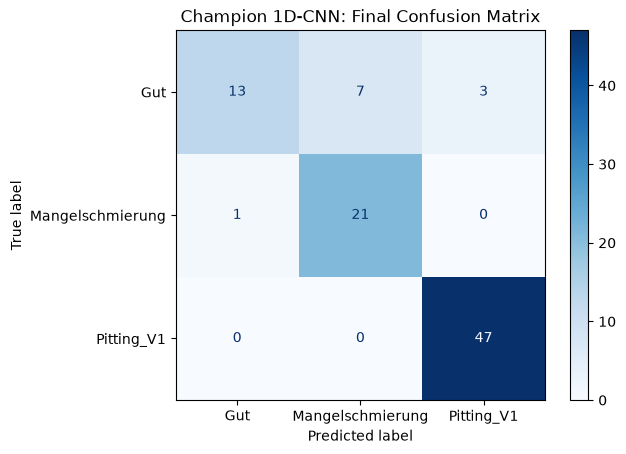

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Building the Champion Model...")

# 1. THE BLUEPRINTS (Using Optuna's winning numbers)
best_lr = 0.0017884144414630936
best_fc_size = 32

class ChampionCNN(nn.Module):
    def __init__(self):
        super(ChampionCNN, self).__init__()
        self.conv1 = nn.Conv1d(2, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(5)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(5)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3200, best_fc_size) # <--- Optuna's Choice
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(best_fc_size, 3)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc2(self.relu3(self.fc1(x)))
        return x

# 2. ASSEMBLE THE ENGINE
champion_model = ChampionCNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(champion_model.parameters(), lr=best_lr) # <--- Optuna's Choice

# 3. TRAIN IT ONE LAST TIME (30 Epochs)
print("Training the Champion Model...")
epochs = 30
for epoch in range(epochs):
    champion_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = champion_model(batch_X.float())
        target_indices = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        loss = criterion(predictions, target_indices)
        loss.backward()
        optimizer.step()

# 4. GATHER THE FINAL EXAM RESULTS
print("Generating Confusion Matrix...")
champion_model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for batch_X, batch_y in val_loader: # Testing against the validation data
        predictions = champion_model(batch_X.float())
        
        predicted_classes = torch.argmax(predictions, dim=1)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        # Save the answers to a list so sklearn can draw the matrix
        all_preds.extend(predicted_classes.cpu().numpy())
        all_trues.extend(true_classes.cpu().numpy())

# 5. DRAW THE MATRIX
cm = confusion_matrix(all_trues, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=selected_classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Champion 1D-CNN: Final Confusion Matrix")
plt.show()

In [33]:
# --- FINAL EXAM: EVALUATE ON TEST DATA ---

# 1. Create the Test DataLoader
test_dataset = DataSet(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Run the Evaluation
print("Running Final Exam on Test Data...")
champion_model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = champion_model(batch_X.float())
        
        predicted_classes = torch.argmax(predictions, dim=1)
        true_classes = torch.argmax(batch_y.view(-1, 3), dim=1).long()
        
        test_total += true_classes.size(0)
        test_correct += (predicted_classes == true_classes).sum().item()

# 3. Calculate Official Accuracy
final_test_accuracy = 100 * test_correct / test_total
print(f"=====================================")
print(f"OFFICIAL TEST ACCURACY: {final_test_accuracy:.2f}%")
print(f"=====================================")

if final_test_accuracy >= 55.0:
    print("Congratulations! The model has officially passed the professor's requirement.")

Running Final Exam on Test Data...
OFFICIAL TEST ACCURACY: 82.80%
Congratulations! The model has officially passed the professor's requirement.
